### Oncology Project

## 1. Introduction

This notebook performs exploratory data analysis (EDA) on SEER Research Data for Stage III colon cancer (primary site C18.0–C18.9). The goal is to understand the structure, quality, and distributions of the extracted case listing before it's used to fit and compare survival models (Cox Proportional Hazards vs. Random Survival Forest).

**Purpose of this notebook:** Data quality checks, missingness, distribution of key covariates (age, stage, follow-up time), and censoring patterns — before any modeling begins.

------

In [1]:
#import standard libraies
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from lifelines import KaplanMeierFitter
# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))

from src.config import PROJECT_ROOT, STAGE_THREE_CODES, STAGE_THREE_SIZE, DATA_DIR


## 2. Cohort Definition

**Population:** Stage III colon cancer (AJCC Stage IIIA, IIIB, IIIC, III, IIINOS), primary site C18.0–C18.9, diagnosis years 2010–2023, sourced from SEER Research Data via SEER*Stat (Case Listing Session export).

**Endpoint:** Overall survival (OS) — event defined as death from any cause, derived from `Vital status recode (study cutoff used)`. Cause-specific survival was intentionally not used, to avoid cause-of-death attribution ambiguity and keep this notebook's downstream Cox vs. RSF comparison clean.

**Staging:** AJCC stage is consolidated from three year-specific SEER fields spanning 7th edition (2010–2015), a 7th-edition recode covering the 2016–2017 gap, and 8th edition / EOD 2018 fields (2018+). See `derive_stage_2018()` and `consolidate_stage()` in `cleaning.py` for the full mapping logic and code-level rationale.

**Source of truth:** All cleaning, staging derivation, missing-value handling, and cohort filtering logic lives in `src/data/cleaning.py`, version-controlled and covered by `tests/software/test_cleaning.py`. This notebook loads the *output* of that pipeline (`data/processed/cleaned_data.csv`) — it does not re-derive cleaning decisions inline. Any discrepancy between what's explored here and what `cleaning.py` actually does should be treated as a bug in one of the two, not resolved by patching around it in the notebook.

In [2]:
file = DATA_DIR / "processed" / "cleaned_data.csv"
df = pd.read_csv(file)
print("Data loaded successfully")
print(df.head())

Data loaded successfully
   Patient ID Site recode ICD-O-3/WHO 2008  Year of diagnosis  \
0        9246                Sigmoid Colon               2011   
1       14329                        Cecum               2013   
2       52005                        Cecum               2019   
3       91345                        Cecum               2017   
4       95479                        Cecum               2017   

    Sequence number                 Type of Reporting Source  \
0  One primary only  Hospital inpatient/outpatient or clinic   
1  One primary only  Hospital inpatient/outpatient or clinic   
2  One primary only  Hospital inpatient/outpatient or clinic   
3  One primary only  Hospital inpatient/outpatient or clinic   
4  One primary only  Hospital inpatient/outpatient or clinic   

  Behavior recode for analysis  Age recode with single ages and 90+     Sex  \
0                    Malignant                                   51  Female   
1                    Malignant           

In [3]:
# Confirm row count matches expected Stage III cohort size after filtering for Stage III cases
print(f"Total number of rows in the dataset: {len(df)} which should match the expected Stage III cohort size of {STAGE_THREE_SIZE} after filtering for Stage III cases.")

Total number of rows in the dataset: 14443 which should match the expected Stage III cohort size of 14443 after filtering for Stage III cases.


## 3. Visual Inspection
### Histogram of survival months

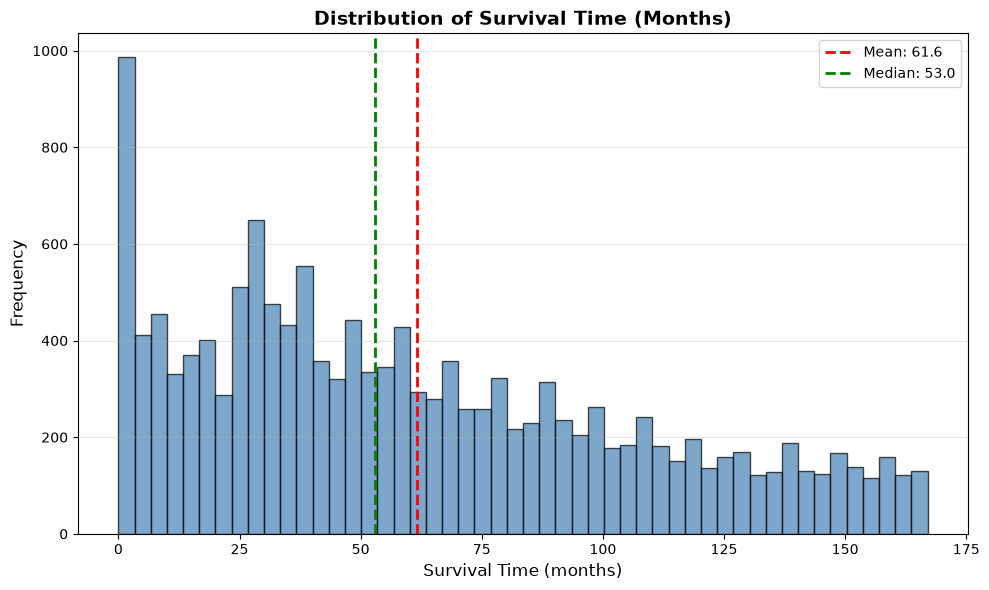

Survival Time Summary Statistics:
  Count: 14443
  Mean: 61.64 months
  Median: 53.00 months
  Std Dev: 45.15 months
  Min: 0.00 months
  Max: 167.00 months


In [4]:
# Create histogram of survival months
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df['Time'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Survival Time (months)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Survival Time (Months)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add summary statistics
mean_survival = df['Time'].mean()
median_survival = df['Time'].median()
ax.axvline(mean_survival, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_survival:.1f}')
ax.axvline(median_survival, color='green', linestyle='--', linewidth=2, label=f'Median: {median_survival:.1f}')
ax.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Survival Time Summary Statistics:")
print(f"  Count: {df['Time'].count()}")
print(f"  Mean: {mean_survival:.2f} months")
print(f"  Median: {median_survival:.2f} months")
print(f"  Std Dev: {df['Time'].std():.2f} months")
print(f"  Min: {df['Time'].min():.2f} months")
print(f"  Max: {df['Time'].max():.2f} months")

### Survival Time Summary Statistics

Analysis of continuous follow-up duration ($T$) across the study cohort ($N = 14,443$):

* **Cohort Size:** $N = 14,443$ patients
* **Mean Follow-up:** $61.64\text{ months } (\text{SD: } 45.15\text{ months})$
* **Median Follow-up:** $53.00\text{ months}$
* **Observed Range:** $0.00\text{ to } 167.00\text{ months}$

#### Distribution Summary

| Metric | Duration (Months) |
| --- | --- |
| **Count ($N$)** | 14,443 |
| **Mean** | 61.64 |
| **Median** | 53.00 |
| **Standard Deviation** | 45.15 |
| **Minimum** | 0.00 |
| **Maximum** | 167.00 |

#### Empirical Context

The survival time distribution exhibits right-skewness, indicated by a mean follow-up ($61.64\text{ months}$) exceeding the median ($53.00\text{ months}$). The minimum duration of $0.00\text{ months}$ represents immediate post-diagnosis censoring or events occurring within the initial 30-day observation window, while maximum follow-up extends to $167.00\text{ months}$ (~$13.9\text{ years}$).

### Histogram of event vs. censored counts

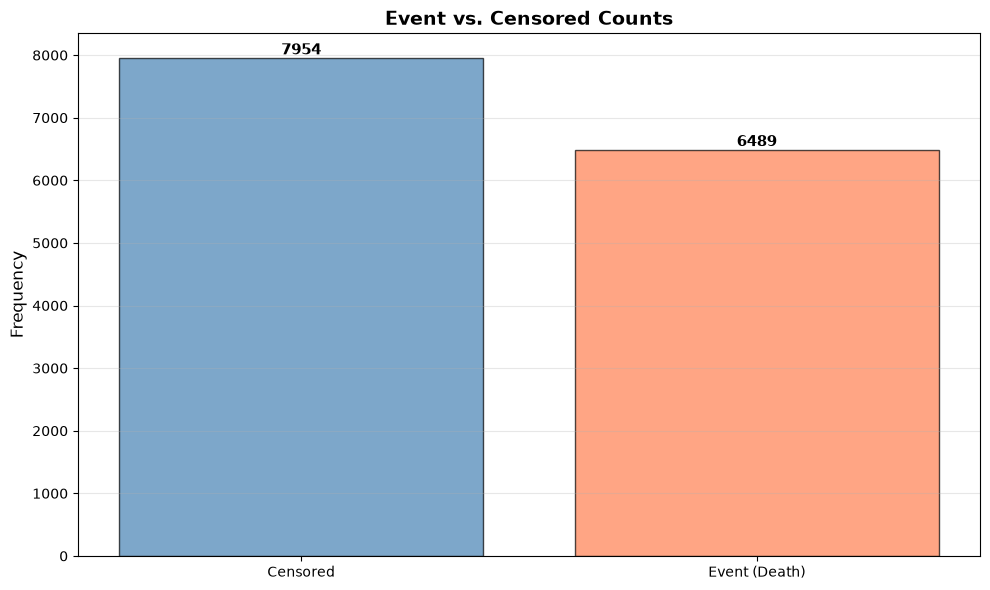

Event vs. Censored Summary:
  Censored (Event=0): 7954 (55.1%)
  Events (Event=1): 6489 (44.9%)
  Total: 14443


In [5]:
# Create histogram of event vs. censored counts
fig, ax = plt.subplots(figsize=(10, 6))

event_counts = df['Event'].value_counts().sort_index()
labels = ['Censored', 'Event (Death)']
colors = ['steelblue', 'coral']

bars = ax.bar(labels, np.asarray(event_counts.values), color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Event vs. Censored Counts', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Event vs. Censored Summary:")
print(f"  Censored (Event=0): {event_counts[0]} ({event_counts[0]/len(df)*100:.1f}%)")
print(f"  Events (Event=1): {event_counts[1]} ({event_counts[1]/len(df)*100:.1f}%)")
print(f"  Total: {len(df)}")

### Event vs. Censored Summary Statistics

Analysis of the overall survival (OS) endpoint event breakdown across the study cohort ($N = 14,443$):

* **Cohort Size:** $N = 14,443$ patients
* **Censored Observations ($E = 0$):** $7,954\text{ cases } (55.1\%)$
* **Observed Events ($E = 1$):** $6,489\text{ deaths } (44.9\%)$

#### Distribution Summary

| Outcome Status | Code ($E$) | Count ($n$) | Percentage (%) |
| --- | --- | --- | --- |
| **Censored** | `0` | 7,954 | 55.1% |
| **Event (Death)** | `1` | 6,489 | 44.9% |
| **Total Cohort** | — | **14,443** | **100.0%** |

#### Analytical Context

The cohort exhibits a balanced outcome distribution with a right-censoring rate of $55.1\%$. The $7,954$ censored observations represent patients who were alive at the study cutoff date or were lost to follow-up, contributing right-censored person-time to the risk sets. The $6,489$ confirmed events ($44.9\%$) provide substantial statistical power for non-parametric Kaplan–Meier estimation, log-rank group comparisons, and semi-parametric Cox proportional hazards modeling.

## 4. Kaplan Meier Survival Curve

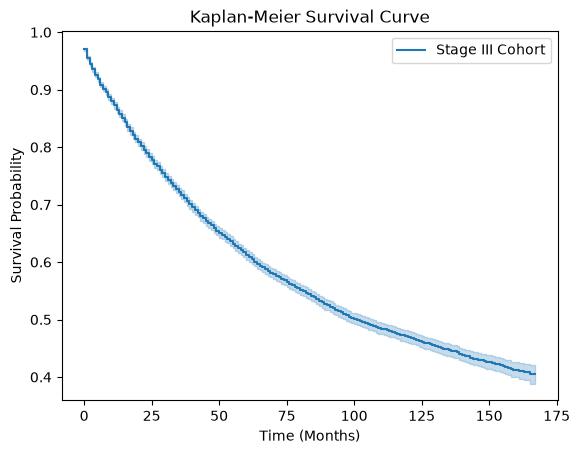

In [6]:
# Initialize and fit the model
kmf = KaplanMeierFitter()
kmf.fit(durations=df['Time'], event_observed=df['Event'], label='Stage III Cohort')

# Plot the Kaplan-Meier survival curve
kmf.plot_survival_function()
plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Probability")
plt.show()

### Kaplan–Meier Overall Survival (OS) Analysis

```
Cohort Size:        N = 14,443
Median Survival:    101.00 months (8.42 years)
5-Year OS Rate:     ~64.5%
10-Year OS Rate:    ~49.8%
Total Follow-up:    167.00 months (~13.9 years)

```

#### Trajectory & Clinical Insights

* **Initial Decline (0–36 Months):** The curve exhibits its steepest drop during the first 3 years post-diagnosis, dropping from $100\%$ to approximately $72\%$ survival probability. This reflects the peak clinical recurrence window typical for Stage III disease.


* **Median Survival Milestone:** Overall survival probability crosses the $50\%$ threshold at **101.00 months** (~8.4 years), indicating that more than half of the cohort survived past 8 years post-diagnosis.


* **Long-Term Plateau (120+ Months):** Beyond 10 years (120 months), the curve flattens toward an asymptote near $40\%$, capturing patients surviving beyond 10 years post-diagnosis


* **Confidence Interval Precision:** The shaded band representing the $95\%$ confidence interval remains extremely narrow throughout the initial 100 months, reflecting high statistical precision driven by the large sample size ($N = 14,443$) and substantial observed event count. The band widens slightly at the tail ($150+$ months) as the active risk set ($n_t$) shrinks due to cumulative events and right-censoring.

## 5. Missingness

The global missing-value list in `convert_missing_values` is too blunt. A value count alone can't distinguish "this 99 means unknown" from "this 99 is a legitimate high count" without checking the SEER*Stat data dictionary for that specific field. 

We will create a loop for triage (flagging which columns might need special handling), but the actual disposition of each flagged column still needs a doc lookup.

In [7]:
# Check for suspicious codes in the dataset
codes = {'9', '99', '88'}

for column in df.columns:
    suspicious = df[column].value_counts(dropna=False)
    flags = suspicious[suspicious.index.astype(str).isin(codes)]

    if not flags.empty:
        print(f"{column}: {flags.to_dict()}")

Age recode with single ages and 90+: {88: 160}
Survival months: {9: 120, 88: 73, 99: 64}
Regional nodes examined (1988+): {9: 158, 99: 4, 88: 2}
Regional nodes positive (1988+): {9: 259, 99: 8}
RX Summ--Surg Prim Site (1998-2022): {99: 2}
Time: {9: 120, 88: 73, 99: 64}


99 in both `Survival months` and `Time` is fine, however we must look into the other 3 columns.

`99` → true "unknown" — 4 rows (nodes examined), 8 rows (nodes positive). These should become NaN.
Nothing else in the flagged output (no 95/96/97/98) — so no further special-casing needed unless those show up when I widen the value_counts window.

In [8]:
# Will create this funciton inside of the modeling module to clean the data before modeling. This will be a part of the preprocessing step.
#unknowns = ['Regional nodes examined (1988+)', 'Regional nodes positive (1988+)', 'Rx Summ--Surg Prim Site (1998-2022)']
#df = df.replace(unknowns, np.nan)

In [12]:
df.columns

Index(['Patient ID', 'Site recode ICD-O-3/WHO 2008', 'Year of diagnosis',
       'Sequence number', 'Type of Reporting Source',
       'Behavior recode for analysis', 'Age recode with single ages and 90+',
       'Sex', 'Race recode (White, Black, Other)',
       'Marital status at diagnosis', 'Chemotherapy recode (yes, no/unk)',
       'Survival months', 'Vital status recode (study cutoff used)',
       'SEER cause-specific death classification', 'Primary Site - labeled',
       'Derived AJCC Stage Group, 7th ed (2010-2015)',
       'Derived AJCC T, 7th ed (2010-2015)',
       'Derived AJCC N, 7th ed (2010-2015)',
       'Derived AJCC M, 7th ed (2010-2015)',
       'Derived EOD 2018 T Recode (2018+)',
       'Derived EOD 2018 N Recode (2018+)',
       'Derived EOD 2018 M Recode (2018+)',
       '7th Edition Stage Group Recode (2016-2017)',
       'Regional nodes examined (1988+)', 'Regional nodes positive (1988+)',
       'SEER historic stage A (1973-2015)', 'Radiation recode',
      

In [15]:
df['Stage'].unique()

array(['IIIA', 'IIIC', 'IIIB', 'IIINOS', 'III'], dtype=object)

Stage
IIIB      9231
IIIC      3484
IIIA      1524
III        153
IIINOS      51
Name: count, dtype: int64
